# Part V — Vectors
### Chapters 121–150

---

## What This Part Covers

Part V is where mathematics stops being about individual numbers and starts being about **direction, magnitude, and relationship**.

A vector is not a list. It is a mathematical object that lives in space, has a direction, and can be combined with other vectors in structured ways. That distinction — object vs container — is the mental shift this Part demands.

You will cover:
- What a vector is geometrically, algebraically, and computationally
- How vectors are added, scaled, and compared
- The dot product: the central operation of vector geometry and ML
- Projections, angles, and orthogonality
- The cross product and orientation in 3D
- Vector spaces: the abstract structure underlying all of this
- NumPy vectorization: how these concepts map to performance
- Three full projects: a visualizer, a particle simulation, and a physics engine

---

## The Mental Shift

In Parts I–IV, you worked with scalars and scalar functions: single numbers, transformations on the number line, and 2D coordinates treated as pairs.

In Part V, **the basic unit of computation becomes the vector**.

This shift has consequences:

| Scalar thinking | Vector thinking |
|---|---|
| How big? | How big AND which direction? |
| Add two numbers | Add two arrows |
| Multiply by a constant | Stretch or flip an arrow |
| Distance on a number line | Distance in n-dimensional space |
| One equation, one unknown | One equation, n unknowns |

Machine learning lives entirely in vector thinking. A datapoint is a vector. A weight matrix row is a vector. A gradient is a vector. If you cannot reason about vectors fluently, you cannot reason about ML fluently.

---

## Part Map — What Connects to What

```
ch121 What is a Vector?
    └─► ch122 Geometric Interpretation
    └─► ch123 Vectors in Programming
           └─► ch124 Vector Representation
           └─► ch125 Vector Addition
           └─► ch126 Scalar Multiplication
                  └─► ch127 Linear Combination
                  └─► ch128 Vector Length (Norm)
                         └─► ch129 Distance in Vector Space
                         └─► ch130 Direction Vectors

ch131 Dot Product Intuition
    └─► ch132 Geometric Meaning of Dot Product
    └─► ch133 Angles Between Vectors
    └─► ch134 Projections
    └─► ch135 Orthogonality

ch136 Cross Product

ch137 Vector Spaces
    └─► ch138 Subspaces
    └─► ch139 Basis and Dimension
    └─► ch140 Span
    └─► ch141 Linear Independence
    └─► ch142 Coordinate Systems

ch143 Vector Transformations
ch144 Vectors in Physics
ch145 Vectors in Machine Learning
ch146 Vectorization for Performance
ch147 NumPy Vector Operations

ch148 Project: Vector Visualizer
ch149 Project: Particle Simulation
ch150 Project: Vector-Based Game Physics
```

The first cluster (ch121–130) builds the object and its basic algebra.
The second cluster (ch131–135) builds the inner product structure — the geometry of angles and projections.
The third cluster (ch136–142) builds the abstract structure: what makes something a vector space.
The final cluster (ch143–147) connects vectors to physics, ML, and computation.
The three projects synthesize everything.

---

## Prerequisites from Prior Parts

- **Part II (ch021–050):** Real numbers, floating-point representation (ch038), square roots and norms
- **Part III (ch051–090):** Functions as transformations (ch052–053), domain and range (ch054)
- **Part IV (ch091–120):** Cartesian coordinates (ch093), distance between points (ch094), slopes and lines (ch097), geometric transformations (ch109–115), trigonometry (ch101–103)

If you cannot compute the distance between two 2D points from coordinates, go back to ch094 before continuing.
If you cannot compute sin and cos from unit circle intuition, go back to ch103.

---

## Motivating Problem — What You Cannot Yet Solve

Below is a problem you will be able to solve completely by ch135.

Run the cell. Read the output. You should not yet be able to explain *why* this works or implement it from scratch.

Similarity A vs B: 0.1952
Similarity A vs C: 0.4280
Similarity B vs C: 0.9355

Most similar pair: B,C


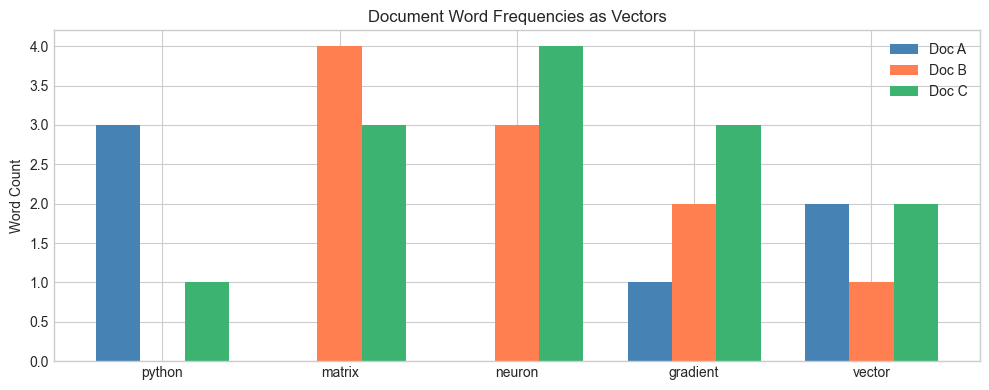

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# --- Motivating Problem: Document Similarity ---
# We have three short 'documents', represented as word-frequency vectors.
# The question: which two documents are most similar in content?

# Vocabulary: ["python", "matrix", "neuron", "gradient", "vector"]
doc_A = np.array([3, 0, 0, 1, 2], dtype=float)  # A programming tutorial
doc_B = np.array([0, 4, 3, 2, 1], dtype=float)  # A linear algebra reference
doc_C = np.array([1, 3, 4, 3, 2], dtype=float)  # A neural network article

def cosine_similarity(u, v):
    """Similarity based on the angle between two vectors."""
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

sim_AB = cosine_similarity(doc_A, doc_B)
sim_AC = cosine_similarity(doc_A, doc_C)
sim_BC = cosine_similarity(doc_B, doc_C)

print(f"Similarity A vs B: {sim_AB:.4f}")
print(f"Similarity A vs C: {sim_AC:.4f}")
print(f"Similarity B vs C: {sim_BC:.4f}")
print()
print("Most similar pair:", max([("A,B", sim_AB), ("A,C", sim_AC), ("B,C", sim_BC)], key=lambda x: x[1])[0])

# --- Visualization ---
labels = ["python", "matrix", "neuron", "gradient", "vector"]
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width, doc_A, width, label='Doc A', color='steelblue')
ax.bar(x, doc_B, width, label='Doc B', color='coral')
ax.bar(x + width, doc_C, width, label='Doc C', color='mediumseagreen')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Document Word Frequencies as Vectors')
ax.set_ylabel('Word Count')
ax.legend()
plt.tight_layout()
plt.show()

**Questions you cannot yet answer:**
1. Why does `np.dot(u, v)` measure similarity? What is it computing geometrically?
2. Why do we divide by `norm(u) * norm(v)`? What does that normalize?
3. If two documents had identical word proportions but different lengths, would they be similar or dissimilar?
4. What does it mean for two vectors to be *orthogonal* in this context?

By ch135, you will be able to answer all four from first principles and implement this from scratch.

---

## A Note on Abstraction

Part V introduces two levels of the same idea:

**Concrete:** A vector is an arrow in 2D or 3D space. You can draw it.

**Abstract:** A vector is any object that obeys the vector space axioms — addition and scalar multiplication with specific properties. Word-frequency lists, probability distributions, and function approximations can all be vectors.

We will build the concrete intuition first and arrive at the abstract definition naturally. The abstraction is earned, not assumed.

---

*Begin with ch121 — What is a Vector?*